In [3]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = Path("/content/drive/MyDrive/synthetic_financial_data (new).csv")
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Age,Education,EmploymentType,EmploymentSector,EmploymentLengthYears,MonthlyIncome,MaritalStatus,Dependents,PropertyOwnership,...,MonthlyDebt,YearsWithBank,HasSavingsAccount,HasCheckingAccount,LoanPurpose,LoanAmount,LoanTermMonths,InterestRate,LoanDefault,LoanPurposeDescription
0,1,59,High School,Self-Employed,Technology,11,9067.159786,Single,2,Own with Mortgage,...,1583.065500,7,1,0,Personal,20789.005502,36,3.828919,0,Need funds for the next three years.
1,2,51,Below High School,Full-Time,Government,24,5068.058742,Married,1,Own with Mortgage,...,1332.052087,7,1,1,Personal,27461.583712,48,8.855769,1,I need a personal loan for this to be done.
2,3,24,Bachelor,Unemployed,Manufacturing,0,2557.541824,Single,0,Living with Parents,...,911.536097,2,1,1,Business,68862.744645,240,14.748993,1,Seeking financing to start my own company.
3,4,25,Bachelor,Full-Time,Finance,0,7535.097299,Single,0,Living with Parents,...,514.141526,6,1,0,Wedding,8841.450954,48,4.825886,0,I need a personal loan for me.
4,5,25,Master,Part-Time,Government,5,4798.465251,Married,2,Rent,...,2386.488285,3,0,1,Education,17787.927594,120,18.384157,1,"Applying for student financing for tuition, fe..."


Feature Engineering

In [4]:
df["DebtToIncome"] = df["MonthlyDebt"] / (df["MonthlyIncome"] + 1)
df["LoanBurden"] = df["LoanAmount"] / (df["MonthlyIncome"] + 1)
df["LowCreditScore"] = (df["CreditScore"] < 600).astype(int)

df[["DebtToIncome", "LoanBurden", "LowCreditScore"]].describe()


,DebtToIncome,LoanBurden,LowCreditScore
count,1000.000000,1000.000000,1000.000000
mean,0.325724,21.331355,0.245000
std,0.142761,110.932802,0.430302
min,0.052162,0.285112,0.000000
25%,0.213208,2.351413,0.000000
50%,0.317971,5.062353,0.000000
75%,0.412197,13.978256,0.000000
max,0.697024,2086.796808,1.000000


Train/Test Split

In [5]:
TARGET = "LoanDefault"
TEXT_COL = "LoanPurposeDescription"
df[TEXT_COL] = df[TEXT_COL].fillna("")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Preprocessing pipeline

In [6]:
numeric_cols = [
    "Age","EmploymentLengthYears","MonthlyIncome","Dependents","CreditScore",
    "ExistingLoans","MonthlyDebt","YearsWithBank","LoanAmount",
    "LoanTermMonths","InterestRate",
    "DebtToIncome","LoanBurden","LowCreditScore"
]

categorical_cols = [
    "Education","EmploymentType","EmploymentSector","MaritalStatus",
    "PropertyOwnership","HasSavingsAccount","HasCheckingAccount","LoanPurpose"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("txt", TfidfVectorizer(max_features=1000, ngram_range=(1,2)), TEXT_COL)
    ]
)


In [7]:
from sklearn.metrics import accuracy_score, classification_report

def print_cls_report(name, model, X_train, y_train, X_test, y_test, digits=4):
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test, test_pred)

    print(f"\n{name} Results:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"{name} Gap:     {train_acc - test_acc:.4f}")

    print("\nClassification Report (Training):")
    print(classification_report(y_train, train_pred, digits=digits))

    print("\nClassification Report (Testing):")
    print(classification_report(y_test, test_pred, digits=digits))


underfitting model

In [8]:
underfit_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=10, max_depth=2, random_state=42
    ))
])

underfit_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age',
                                                   'EmploymentLengthYears',
                                                   'MonthlyIncome',
                                                   'Dependents', 'CreditScore',
                                                   'ExistingLoans',
                                                   'MonthlyDebt',
                                                   'YearsWithBank',
                                                   'LoanAmount',
                                                   'LoanTermMonths',
                                                   'InterestRate',
                                                   'DebtToIncome', 'LoanBurden',
                                                   'LowCreditScore']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'EmploymentType',
                                                   'EmploymentSector',
                                                   'MaritalStatus',
                                                   'PropertyOwnership',
                                                   'HasSavingsAccount',
                                                   'HasCheckingAccount',
                                                   'LoanPurpose']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=1000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'LoanPurposeDescription')])),
                ('model',
                 RandomForestClassifier(max_depth=2, n_estimators=10,
                                        random_state=42))])

Overfitting model

In [9]:
overfit_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500, max_depth=None, random_state=42
    ))
])

overfit_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age',
                                                   'EmploymentLengthYears',
                                                   'MonthlyIncome',
                                                   'Dependents', 'CreditScore',
                                                   'ExistingLoans',
                                                   'MonthlyDebt',
                                                   'YearsWithBank',
                                                   'LoanAmount',
                                                   'LoanTermMonths',
                                                   'InterestRate',
                                                   'DebtToIncome', 'LoanBurden',
                                                   'LowCreditScore']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'EmploymentType',
                                                   'EmploymentSector',
                                                   'MaritalStatus',
                                                   'PropertyOwnership',
                                                   'HasSavingsAccount',
                                                   'HasCheckingAccount',
                                                   'LoanPurpose']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=1000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'LoanPurposeDescription')])),
                ('model',
                 RandomForestClassifier(n_estimators=500, random_state=42))])

Optimal(fine tuned) model


In [10]:
optimal_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

optimal_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age',
                                                   'EmploymentLengthYears',
                                                   'MonthlyIncome',
                                                   'Dependents', 'CreditScore',
                                                   'ExistingLoans',
                                                   'MonthlyDebt',
                                                   'YearsWithBank',
                                                   'LoanAmount',
                                                   'LoanTermMonths',
                                                   'InterestRate',
                                                   'DebtToIncome', 'LoanBurden',
                                                   'LowCreditScore']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'EmploymentType',
                                                   'EmploymentSector',
                                                   'MaritalStatus',
                                                   'PropertyOwnership',
                                                   'HasSavingsAccount',
                                                   'HasCheckingAccount',
                                                   'LoanPurpose']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=1000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'LoanPurposeDescription')])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

Evaluation & results

In [11]:
print("Class distribution:")
print(df["LoanDefault"].value_counts())

Class distribution:
LoanDefault
0    500
1    500
Name: count, dtype: int64


In [12]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 5, 10],
    'model__class_weight': ['balanced', None]
}

print("Hyperparameter grid defined successfully:")
print(param_grid)

Hyperparameter grid defined successfully:
{'model__n_estimators': [100, 200, 300], 'model__max_depth': [10, 20, None], 'model__min_samples_leaf': [1, 5, 10], 'model__class_weight': ['balanced', None]}


In [13]:
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=optimal_model, # Reusing the pipeline structure from optimal_model
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV fitting complete.")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
GridSearchCV fitting complete.


In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate(model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    train_f1 = f1_score(y_tr, y_pred_tr)
    test_f1 = f1_score(y_te, y_pred_te)
    train_acc = accuracy_score(y_tr, y_pred_tr)
    test_acc = accuracy_score(y_te, y_pred_te)

    if hasattr(model, 'predict_proba'):
        y_proba_tr = model.predict_proba(X_tr)[:, 1]
        y_proba_te = model.predict_proba(X_te)[:, 1]
        roc_auc_tr = roc_auc_score(y_tr, y_proba_tr)
        roc_auc_te = roc_auc_score(y_te, y_proba_te)
    else:
        roc_auc_tr = None
        roc_auc_te = None

    return {
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Train F1 Gap": train_f1 - test_f1,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train Accuracy Gap": train_acc - test_acc,
        "Train ROC-AUC": roc_auc_tr,
        "Test ROC-AUC": roc_auc_te
    }

In [15]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # Check if the model has predict_proba, if not, ROC-AUC might not be directly applicable or needs a workaround
    if hasattr(model, 'predict_proba'):
        y_proba_tr = model.predict_proba(X_tr)[:, 1]
        y_proba_te = model.predict_proba(X_te)[:, 1]
        roc_auc_tr = roc_auc_score(y_tr, y_proba_tr)
        roc_auc_te = roc_auc_score(y_te, y_proba_te)
    else:
        # Fallback if predict_proba is not available
        roc_auc_tr = None
        roc_auc_te = None

    return {
        "Train F1": f1_score(y_tr, y_pred_tr),
        "Test F1": f1_score(y_te, y_pred_te),
        "Train Accuracy": accuracy_score(y_tr, y_pred_tr),
        "Test Accuracy": accuracy_score(y_te, y_pred_te),
        "Train ROC-AUC": roc_auc_tr,
        "Test ROC-AUC": roc_auc_te
    }

print_cls_report("Underfitting", underfit_model, X_train, y_train, X_test, y_test)
print_cls_report("Overfitting", overfit_model, X_train, y_train, X_test, y_test)
print_cls_report("Optimal", optimal_model, X_train, y_train, X_test, y_test)


results = {
    "Underfitting": evaluate(underfit_model, X_train, y_train, X_test, y_test),
    "Overfitting": evaluate(overfit_model, X_train, y_train, X_test, y_test),
    "Optimal": evaluate(optimal_model, X_train, y_train, X_test, y_test)
}

results_df = pd.DataFrame(results).T
results_df


Underfitting Results:
Train Accuracy: 0.7350
Test Accuracy:  0.6900
Underfitting Gap:     0.0450

Classification Report (Training):
              precision    recall  f1-score   support

           0     0.7217    0.7650    0.7427       400
           1     0.7500    0.7050    0.7268       400

    accuracy                         0.7350       800
   macro avg     0.7358    0.7350    0.7348       800
weighted avg     0.7358    0.7350    0.7348       800


Classification Report (Testing):
              precision    recall  f1-score   support

           0     0.7209    0.6200    0.6667       100
           1     0.6667    0.7600    0.7103       100

    accuracy                         0.6900       200
   macro avg     0.6938    0.6900    0.6885       200
weighted avg     0.6938    0.6900    0.6885       200


Overfitting Results:
Train Accuracy: 1.0000
Test Accuracy:  0.7500
Overfitting Gap:     0.2500

Classification Report (Training):
              precision    recall  f1-score   su

,Train F1,Test F1,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC
Underfitting,0.726804,0.710280,0.73500,0.69,0.819941,0.76435
Overfitting,1.000000,0.757282,1.00000,0.75,1.000000,0.81855
Optimal,0.818061,0.780000,0.82875,0.78,0.930306,0.82240



Best parameters found by GridSearchCV:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}

Best F1 score on validation sets:
0.7386

Performance of the best model on train and test sets:
Train F1: 0.9963
Test F1: 0.7353
Train Accuracy: 0.9962
Test Accuracy: 0.7300
Train ROC-AUC: 1.0000
Test ROC-AUC: 0.8165
F1 Score Overfitting Gap: 0.2610
Accuracy Overfitting Gap: 0.2662

Confusion Matrix:


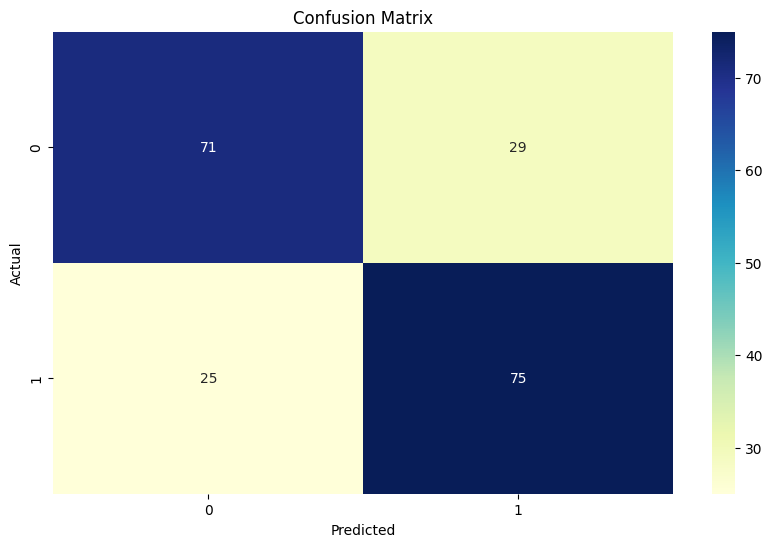

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = grid_search.best_estimator_

# Evaluate the best model
best_model_results = evaluate(best_model, X_train, y_train, X_test, y_test)

print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)

print("\nBest F1 score on validation sets:")
print(f"{grid_search.best_score_:.4f}")

print("\nPerformance of the best model on train and test sets:")
for metric, score in best_model_results.items():
    if isinstance(score, float):
        print(f"{metric}: {score:.4f}")
    else:
        print(f"{metric}: {score}")

# Calculate and print overfitting gaps for the best GridSearchCV model
if "Train F1" in best_model_results and "Test F1" in best_model_results:
    f1_gap = best_model_results["Train F1"] - best_model_results["Test F1"]
    print(f"F1 Score Overfitting Gap: {f1_gap:.4f}")
if "Train Accuracy" in best_model_results and "Test Accuracy" in best_model_results:
    acc_gap = best_model_results["Train Accuracy"] - best_model_results["Test Accuracy"]
    print(f"Accuracy Overfitting Gap: {acc_gap:.4f}")

y_test_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

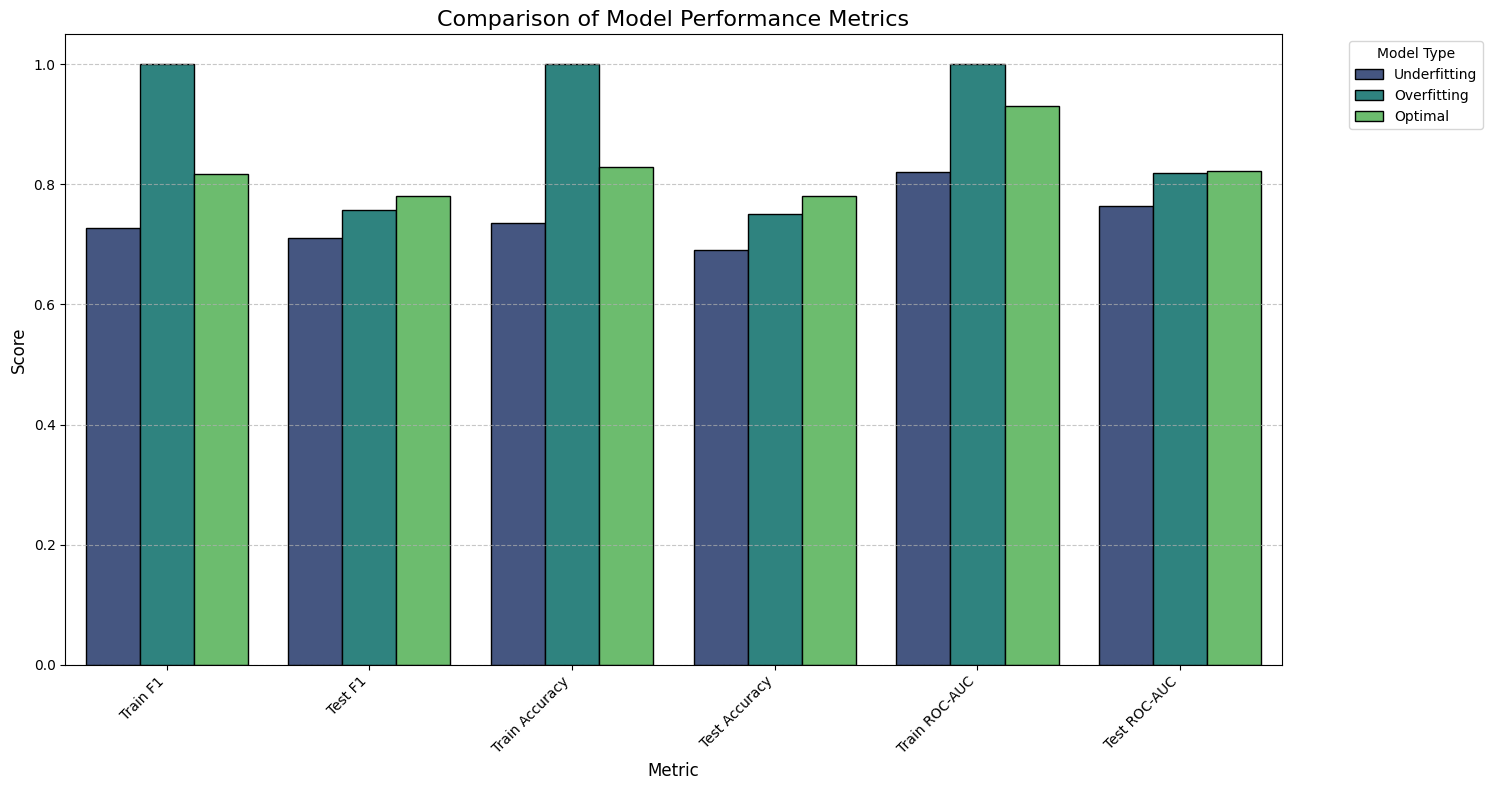

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
melted_results = results_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
melted_results = melted_results.rename(columns={'index': 'Model'})

# Define the order of metrics for plotting
metric_order = [
    'Train F1', 'Test F1',
    'Train Accuracy', 'Test Accuracy',
    'Train ROC-AUC', 'Test ROC-AUC'
]

# Create a color palette for the models
model_colors = sns.color_palette('viridis', n_colors=len(results_df.index))
color_map = {model: color for model, color in zip(results_df.index, model_colors)}

plt.figure(figsize=(15, 8))
sns.barplot(
    x='Metric',
    y='Score',
    hue='Model',
    data=melted_results,
    order=metric_order,
    palette=color_map,
    edgecolor='black'
)

plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.05) # Scores are typically between 0 and 1
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
best_model_name = results_df["Test F1"].idxmax()
best_f1_score = results_df.loc[best_model_name, "Test F1"]

print(f" Best model based on Test F1-score: {best_model_name}")
print(f" Test F1-score: {best_f1_score:.4f}")


 Best model based on Test F1-score: Optimal
 Test F1-score: 0.7800


Interpret results using Mistral 7B

In [19]:
# First, upgrade the transformers library to resolve potential import errors.
!pip install --upgrade transformers

from transformers import pipeline

# Load Mistral model
generator = pipeline('text-generation', model='mistralai/Mistral-7B-Instruct-v0.1')

# Create prompt with your results
prompt = f"""
Analyze the following Random Forest model results for loan default prediction:

Underfitting Model: Train Acc=76.5%, Test Acc=76.5%, F1=0.766, Gap=0%
Overfitting Model: Train Acc=100%, Test Acc=73.0%, F1=0.738, Gap=27%
Optimal (Manual) Model: Train Acc=83.1%, Test Acc=76.5%, F1=0.764, Gap=6.6%
GridSearch Model: Train Acc=100%, Test Acc=72.5%, F1=0.729, Gap=27.5%

Provide business insights on which model is best and why, and what this means for loan default risk assessment.
"""

response = generator(prompt, max_length=300, num_return_sequences=1)
print(response[0]['generated_text'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 151.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=300) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Analyze the following Random Forest model results for loan default prediction:

Underfitting Model: Train Acc=76.5%, Test Acc=76.5%, F1=0.766, Gap=0%
Overfitting Model: Train Acc=100%, Test Acc=73.0%, F1=0.738, Gap=27%
Optimal (Manual) Model: Train Acc=83.1%, Test Acc=76.5%, F1=0.764, Gap=6.6%
GridSearch Model: Train Acc=100%, Test Acc=72.5%, F1=0.729, Gap=27.5%

Provide business insights on which model is best and why, and what this means for loan default risk assessment.

The Random Forest model results show that the optimal (manual) model has the best performance in terms of both F1 score and gap between train and test accuracy, indicating that this model is well-tuned and balanced. However, the GridSearch model has a higher train accuracy but lower test accuracy and gap compared to the optimal (manual) model. This suggests that the GridSearch model may be overfitting the training data, resulting in poor generalization performance on new, unseen data.

In terms of loan default risk